# Maximal Example: Full Processing Pipeline

Demonstrates the complete USTB processing chain:
1. **Demodulation** — RF to IQ conversion
2. **DAS beamforming** — with transmit-dimension only (keeps Rx channels)
3. **Coherence factor** — Mallart-Fink adaptive weighting
4. **Median filter** — speckle reduction

This is the Python equivalent of the MATLAB `maximal_example.m`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

## Download and read dataset

In [2]:
DATA_URL = "https://www.ustb.no/datasets/"
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath(".")), "data")
filename = "Verasonics_P2-4_parasternal_long_small.uff"
filepath = os.path.join(DATA_PATH, filename)

if not os.path.exists(filepath):
    os.makedirs(DATA_PATH, exist_ok=True)
    urllib.request.urlretrieve(DATA_URL + filename, filepath)

from pyuff_ustb.objects.uff import Uff
from pyuff_ustb.objects import SectorScan
from pyuff_ustb.objects.point import Point

channel_data = Uff(filepath).read("channel_data")

sequence = channel_data.sequence
if not isinstance(sequence, (list, tuple)):
    sequence = [sequence]

depth_axis = np.linspace(0e-3, 110e-3, 1024)
azimuth_axis = np.linspace(
    float(sequence[0].source.azimuth),
    float(sequence[-1].source.azimuth),
    len(sequence)
)

scan = SectorScan()
scan.__dict__["azimuth_axis"] = azimuth_axis
scan.__dict__["depth_axis"] = depth_axis
origin = Point()
origin.__dict__["distance"] = 0.0
origin.__dict__["azimuth"] = 0.0
origin.__dict__["elevation"] = 0.0
scan.__dict__["origin"] = origin

print(f"Channel data: {channel_data.N_samples} samples, "
      f"{channel_data.N_channels} channels, "
      f"{channel_data.N_waves} waves")

Channel data: 2176 samples, 64 channels, 101 waves


## Step 1: Demodulation (RF → IQ)

In [3]:
from ustb.preprocess import FastDemodulation

demod = FastDemodulation()
demod.modulation_frequency = float(channel_data.pulse.center_frequency)
demod.input = channel_data
channel_data_demod = demod.go()

print(f"Demodulated: {channel_data_demod.N_samples} samples, "
      f"fc = {channel_data_demod.modulation_frequency/1e6:.1f} MHz")

Demodulated: 2176 samples, fc = 3.0 MHz


## Step 2: DAS Beamforming (transmit dimension)

We beamform only over the transmit dimension, keeping receive channels
separate for the coherence factor computation.

In [4]:
from ustb.midprocess import DAS
from ustb.enums import Dimension, Window

mid = DAS()
mid.channel_data = channel_data_demod
mid.scan = scan
mid.dimension = Dimension.transmit
mid.transmit_apodization.window = Window.scanline
mid.receive_apodization.window = Window.none

b_data = mid.go()
print(f"Beamformed: {b_data.data.shape}")

USTB Python beamformer...

Completed in 205.90 seconds.


Beamformed: (103424, 64, 1, 5)


## Step 3: Coherence Factor

The Mallart-Fink coherence factor weights each pixel by the ratio of
coherent to incoherent energy across receive channels, suppressing
off-axis echoes and improving contrast.

In [5]:
from ustb.postprocess import CoherenceFactor

cf = CoherenceFactor()
cf.dimension = Dimension.receive
cf.input = b_data
b_data_cf = cf.go()

print(f"After CF: {b_data_cf.data.shape}")

After CF: (103424, 1, 1, 5)


## Step 4: Median Filter

A 5×5 median filter reduces remaining speckle noise.

In [6]:
from ustb.postprocess import Median

me = Median()
me.m = 5
me.n = 5
me.input = b_data_cf
b_data_final = me.go()

print(f"After median: {b_data_final.data.shape}")

After median: (103424, 1, 1, 5)


## Display final image

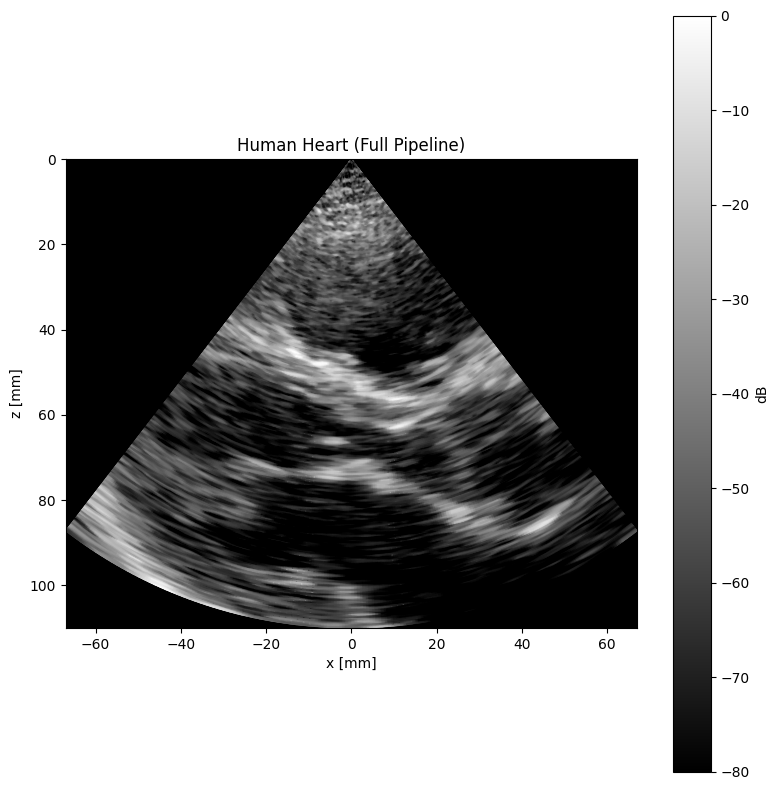

In [7]:
fig, ax = b_data_final.plot(title="Human Heart (Full Pipeline)", dynamic_range=80)
plt.show()